In [1]:
import os
import pickle
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, cm

In [67]:
# emb_datapath = "/home/zachkaras/fmri/fmri_model/analysis/fir/midprocess/133/code_keystroke_embeddings.pkl"
emb_datapath = "/home/zachkaras/fmri/fmri_model_data/fir_embeddings/codegemma_2b/133/code_keystroke_embeddings.pkl"

with open(emb_datapath, 'rb') as f:
    embedding_dict = pickle.load(f)
    
    
keystroke_path = "/home/zachkaras/fmri/fmri_model/analysis/fir/midprocess/133/code_formatted_keystrokes.pkl"

with open(keystroke_path, 'rb') as f:
    keystroke_dict = pickle.load(f)

In [68]:
layers = embedding_dict[(keystroke_dict[55])].keys()

signal = { l : [] for l in layers }
vols_without_keystrokes = []
for vol,keys in keystroke_dict.items():
    
    if keys == '':
        vols_without_keystrokes.append(vol)
        # TODO record and remove volumes without any keystroke data
        continue
    
    layers = embedding_dict[keys]
    for l, emb in layers.items():
        signal[l].append(emb)
    # break

    # np.append(emb)

signal = { l : np.vstack(v) for l,v in signal.items()}    


(688, 2048)

In [ ]:
signal_outpath = f"/home/zchkaras/fmri/fmri_model_data/fir_embeddings/codegemma_2b/133/code_keystroke_embeddings.pkl"


In [14]:
# signal['layer_0'].shape
Rstim = signal['layer_0']
print(Rstim.shape)

(688, 3072)


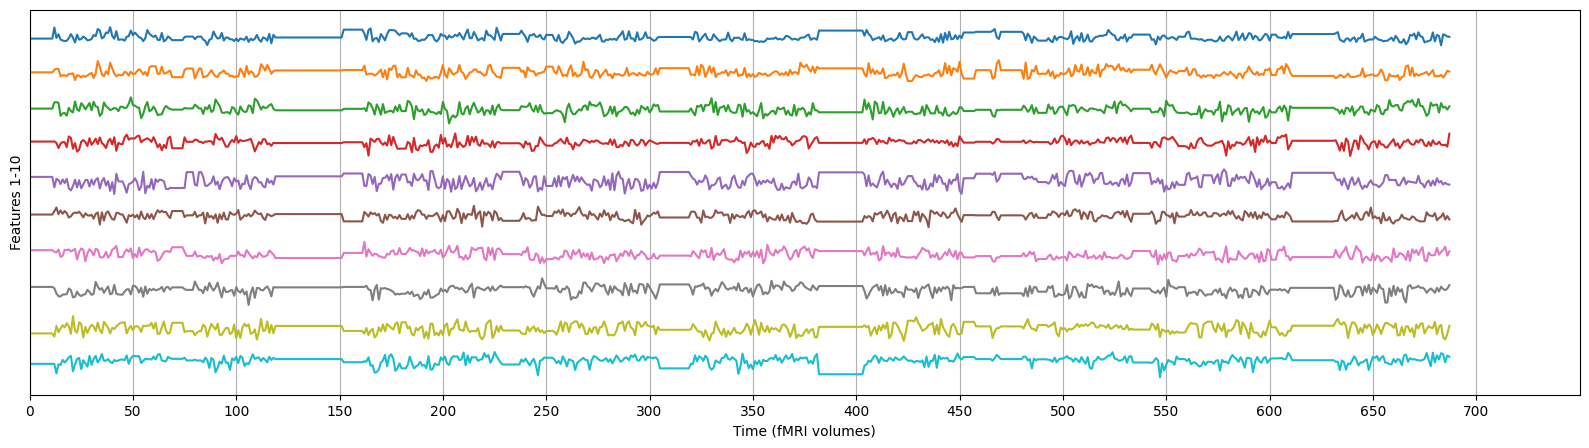

In [15]:
f = figure(figsize=(20, 5))
ax = f.add_subplot(1,1,1)

for ii in range(10):
    # Plot each feature, offset by 5 vertically so they are easier to see
    ax.plot(Rstim[:,ii] - 5 * ii)

ax.set_xlim(0, 750)
ax.set_yticks([])
ax.set_xticks(range(0, 750, 50))
ax.set_xlabel("Time (fMRI volumes)")
ax.set_ylabel("Features 1-10")
ax.grid()

In [16]:
with open("test.pkl", 'rb') as f:
    delayed = pickle.load(f)
delayed.shape

(688, 18432)

In [18]:
2 * Rstim.shape[1]

6144

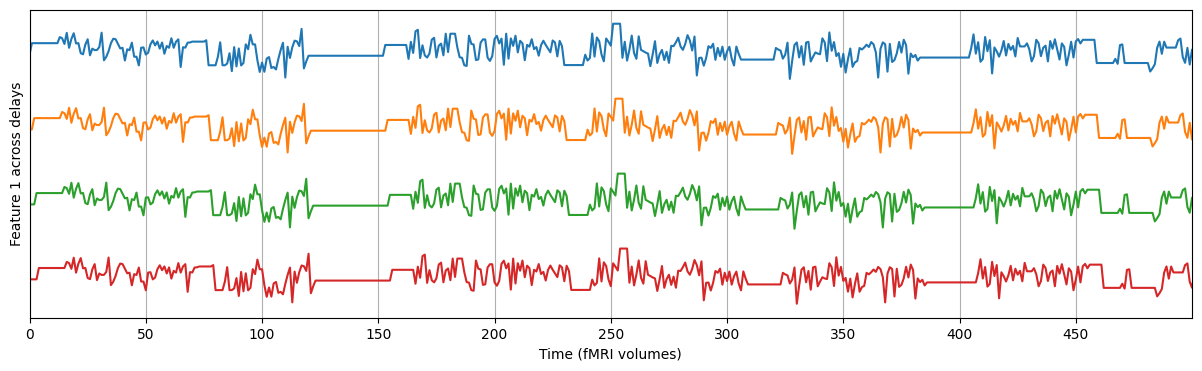

In [24]:
ndelays = 4

f = figure(figsize=(15, 4))
ax = f.add_subplot(1,1,1)
for ii in range(ndelays):
    # print(ii * Rstim.shape[1])
    ax.plot(delayed[:, ii * 4608] - 5 * ii)
    # ax.plot(delayed[:, ii * Rstim.shape[1]] - 5 * ii)
ax.set_xlim(0, 500)
ax.set_yticks([])
ax.set_xticks(range(0, 500, 50))
ax.set_xlabel("Time (fMRI volumes)")
ax.set_ylabel("Feature 1 across delays")
ax.grid()

In [23]:
mask.shape[-1]

91

In [ ]:
# TODO load in fMRI data and partition by Schaefer Atlas parcels
atlas_base_path = "/home/zachkaras/fmri/fmri_model/analysis/pipeline/atlases"

# read in 2d mni mask
mask = nib.load(f"{atlas_base_path}/MNI152_T1_2mm_brain_mask.nii.gz")
mask = mask.get_fdata().flatten()
brain_idx = np.where(mask>0)[0]

atlas = nib.load(f"{atlas_base_path}/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz")
atlas_vec = atlas.get_fdata().flatten()
atlas_only_brain = atlas_vec[brain_idx]
cortex = np.where(atlas_only_brain != 0)[0]

# % Loading and create an empty template image for writing NIfTI files:
# nii_template = load_untouch_nii(maskfile); % load the brain mask for an example in the right (91x109x91) space
# nii_template.img = zeros(size(nii_template.img)); % replace the mask with all 0s
# empty_brain = nii_template.img; % create an empty_brain image in the template's shape

# atlas = niftiread('./atlases/Schaefer2018_400Parcels_7Networks_order_FSLMNI152_2mm.nii.gz'); % let's pretend this is a result or seed region file
# atlas_2d_brain = atlas(brain_idx); % reshapes to 2d within the brain
# read in mni mask
# 


In [ ]:
# load in participants' data

In [ ]:
# len(np.where(atlas_only_brain == 0)[0])
# print(len(atlas_only_brain) - len(np.where(atlas_only_brain == 0)[0]), len(np.where(atlas_only_brain == 0)[0]))

131065

In [5]:

# plt.figure(figsize=(12, 10))

# for i, (key, values) in enumerate(signal.items(), 1):
#     plt.subplot(5, 1, i)
#     plt.plot(values[:2000], label=key, alpha=0.8)
#     plt.ylabel("Value")
#     plt.legend(loc="upper right")
#     if i == 5:
#         plt.xlabel("Index")

# plt.suptitle("First 5000 values from each layer (stacked)", fontsize=14)
# plt.tight_layout(rect=[0, 0, 1, 0.96])
# # plt.show()

In [6]:
# TODO - downsample the signal to match 